### Autocrine KS + Mininal CMIPS 

Two-population model: stable KS + minimal-signalling MIPS
alpha1 = 2.000, alpha2 = 2.000
PeC1 = 0.500, PeC2 = 0.500
a2 = 0.100, k = 0.100, Da0 = 0.500
Aggregate threshold for phi2 = 0.500
Initial chemical steady state c0 = 0.4000
Initial mean phi1 = 0.399960
Initial mean phi2 = 0.400091
Initial mean total density = 0.800051
step = 0, mean total phi = 0.800051, var total = 6.738655e-05, var phi1 = 3.310695e-05, var phi2 = 3.346121e-05, var c = 3.349984e-05, Pearson = 0.012, E1 = nan, aggregate area = 0.000
step = 10000, time = 10.0, mean phi1 = 0.399960, mean phi2 = 0.400091, mean total = 0.800051, var phi1 = 3.060782e-07, var phi2 = 2.386271e-06, var c = 2.887782e-07, Pearson = -0.108, E1 = nan, aggregate area = 0.000
step = 20000, time = 20.0, mean phi1 = 0.399960, mean phi2 = 0.400091, mean total = 0.800051, var phi1 = 1.737561e-07, var phi2 = 8.114227e-06, var c = 1.022516e-06, Pearson = 0.257, E1 = nan, aggregate area = 0.000
step = 30000, time = 30.0, mean phi1 = 0.399960, mean ph

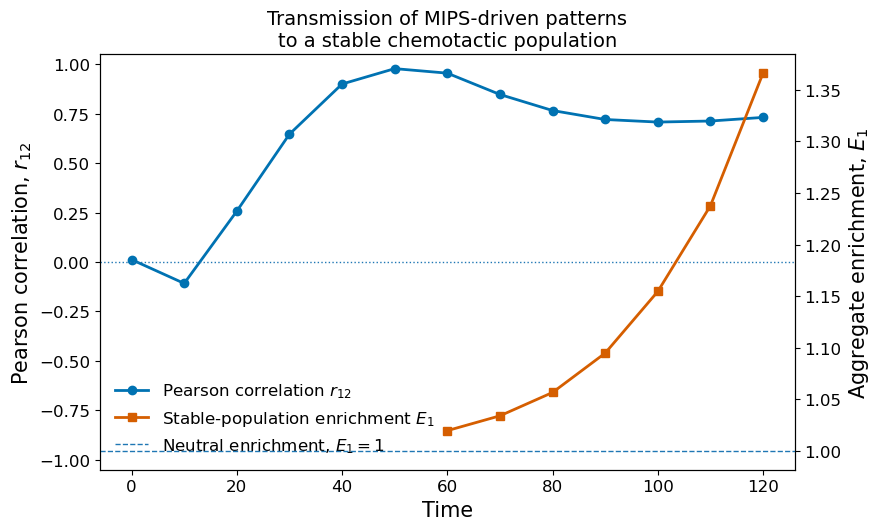

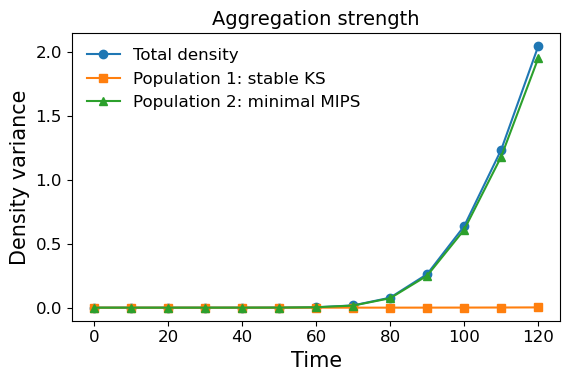

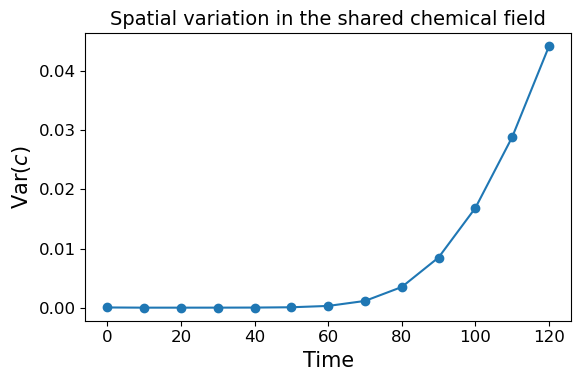

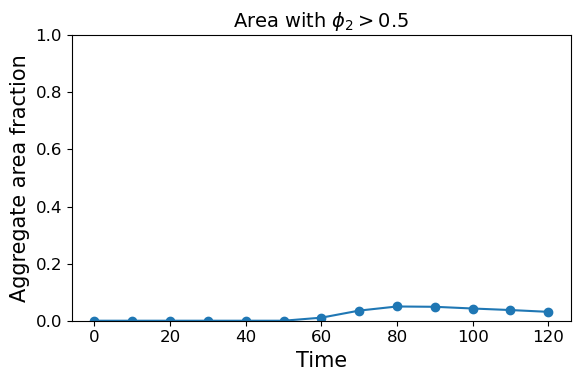

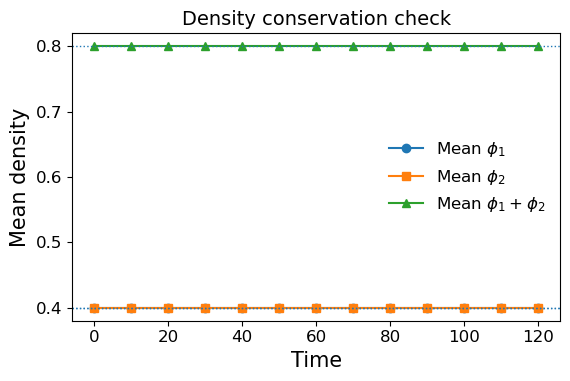

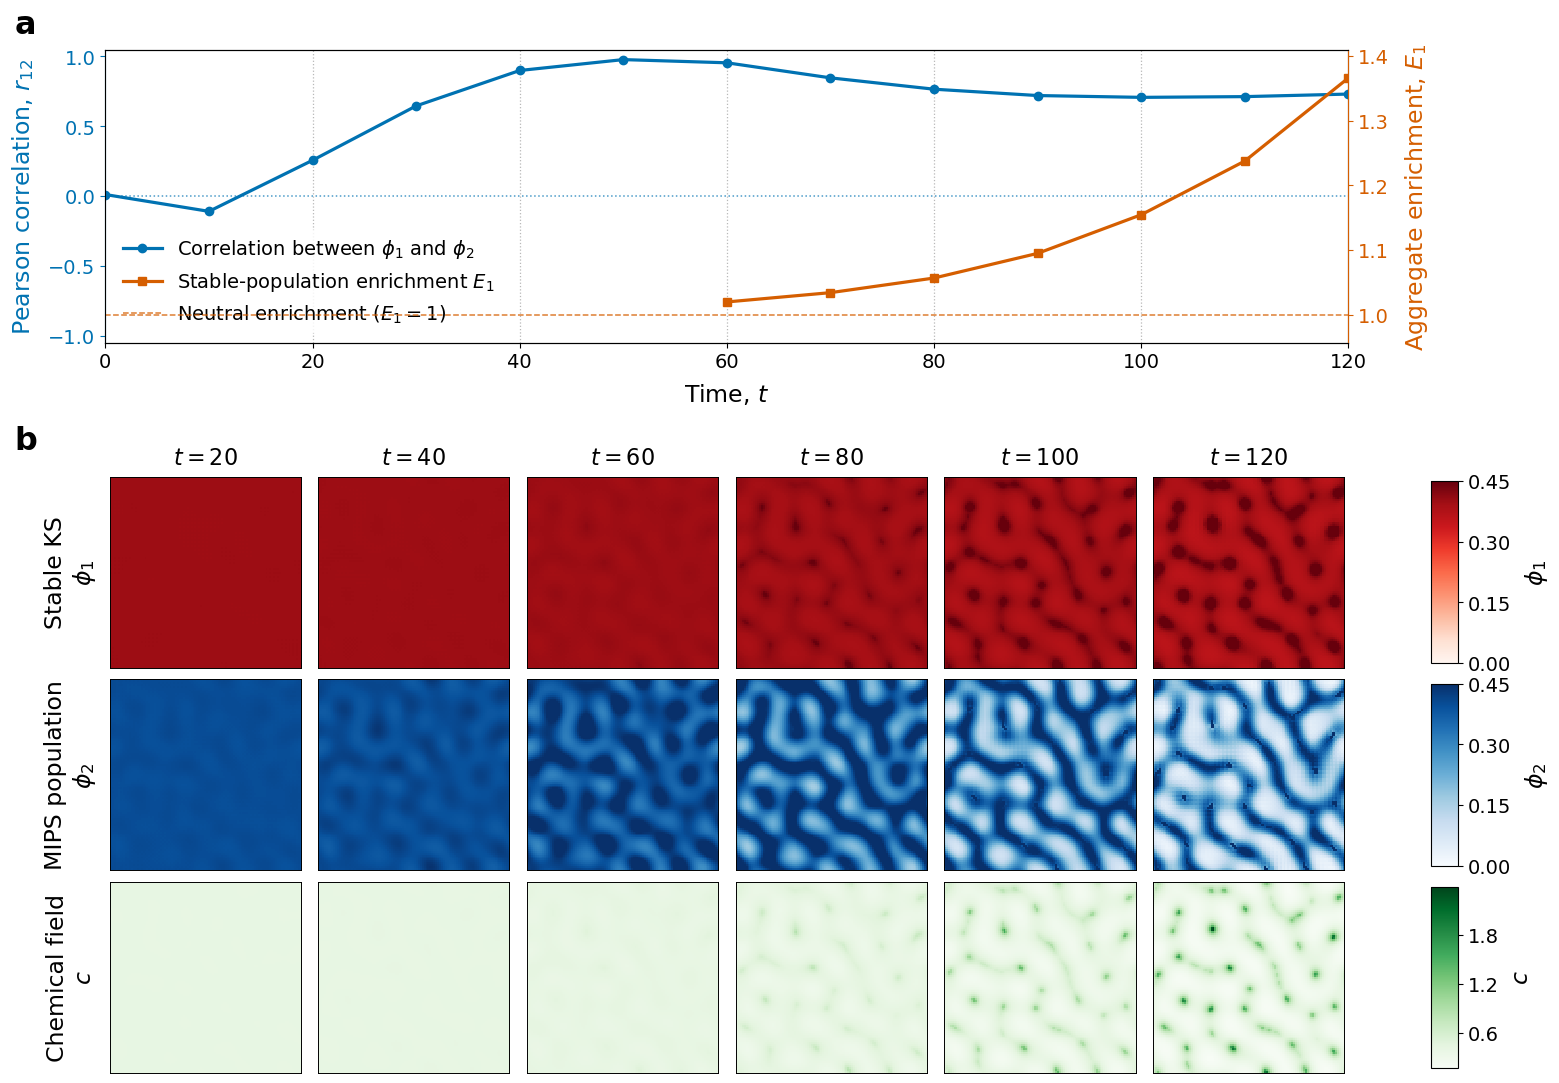

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

# Display settings (simulation parameters and numerical updates unchanged)
SHOW_INTERMEDIATE_PLOTS = False
plt.rcParams.update({"font.size": 13, "axes.labelsize": 15, "axes.titlesize": 14, "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 12, "pdf.fonttype": 42, "ps.fonttype": 42,})

# Two-population simulation
# Population 1: stable diffusive Keller--Segel population
# Population 2: minimal-signaling CMIPS population
# Population 2 produces a shared chemical field.
# Both populations respond chemotactically to the same field.
# Main time-dependent measurements:
# 1. Pearson correlation between phi1 and phi2
# 2. Enrichment of population 1 inside MIPS aggregates
# No clipping or density rescaling during time evolution.

# 1. Grid and time
Nx, Ny = 100, 100
dx = 1.0
dt = 0.001
T = 120000
plot_interval = 10000

np.random.seed(1)

# 2. Model parameters
phi_m = 0.9
phi0_total = 0.8

# Initial mean densities
phi10 = phi0_total / 2
phi20 = phi0_total / 2

# Population 1: stable diffusive KS
D_phi1 = 2
chi1 = 1

# Population 2: minimal-signalling MIPS
M2 = 2
chi2 = 1

Pe_R = 0.001
kappa = 5.0

# Shared chemical field
D_c = 1.0
a2 = 0.1
k = 0.1

# Fixed threshold used to define MIPS aggregates
aggregate_threshold = 0.5

# Dimensionless parameters
alpha1 = D_phi1 / D_c
alpha2 = M2 / D_c

PeC1 = chi1 / D_phi1
PeC2 = chi2 / M2

Da0 = kappa * k / D_c

print("Two-population model: stable KS + minimal-signaling CMIPS")
print(f"alpha1 = {alpha1:.3f}, alpha2 = {alpha2:.3f}")
print(f"PeC1 = {PeC1:.3f}, PeC2 = {PeC2:.3f}")
print(f"a2 = {a2:.3f}, k = {k:.3f}, Da0 = {Da0:.3f}")
print(f"Aggregate threshold for phi2 = {aggregate_threshold:.3f}")

# 3. Finite-difference operators
def laplacian(field, spacing):
    return (np.roll(field, -1, axis=0) + np.roll(field, 1, axis=0) + np.roll(field, -1, axis=1) + np.roll(field, 1, axis=1) - 4.0 * field) / spacing**2

def gradient_x(field, spacing):
    return (np.roll(field, -1, axis=0) - np.roll(field, 1, axis=0)) / (2.0 * spacing)

def gradient_y(field, spacing):
    return (np.roll(field, -1, axis=1) - np.roll(field, 1, axis=1)) / (2.0 * spacing)

# 4. MIPS chemical potential
def compute_mu(phi, phi_m_value, pe_r):
    # This clipping is only used to keep the logarithms defined.
    # It does not modify the evolving phi1 or phi2 fields.
    phi_safe = np.clip(phi, 1e-6, phi_m_value - 1e-6)

    term1 = np.log(phi_safe)
    term2 = 1.0 - 2.0 * phi_safe - 0.3 * phi_safe**2

    term3 = -(4.0 / np.pi) * pe_r * phi_m_value * (np.log(1.0 - phi_safe / phi_m_value) - phi_safe / phi_m_value - phi_safe)

    return term1 + term2 + term3

# 5. Pearson correlation
def compute_pearson(phi1, phi2):
    x = phi1.ravel()
    y = phi2.ravel()

    sigma1 = np.std(x)
    sigma2 = np.std(y)

    if sigma1 < 1e-12 or sigma2 < 1e-12:
        return np.nan

    return np.corrcoef(x, y)[0, 1]

# 6. Aggregate enrichment
def compute_aggregate_enrichment(phi1, phi2, threshold):
    """
    Define MIPS aggregates using:
        phi2 > threshold

    Stable-population enrichment:
        E1 =
        (fraction of phi1 mass inside aggregates)
        /
        (fraction of domain occupied by aggregates)

    E1 = 1: neutral distribution
    E1 > 1: phi1 enriched inside MIPS aggregates
    E1 < 1: phi1 depleted from MIPS aggregates
    """

    aggregate_mask = phi2 > threshold

    area_fraction = np.mean(aggregate_mask)

    total_phi1_mass = np.sum(phi1)

    if area_fraction < 1e-12 or total_phi1_mass < 1e-12:
        return np.nan, area_fraction

    phi1_mass_inside = np.sum(phi1[aggregate_mask])
    phi1_mass_fraction_inside = phi1_mass_inside / total_phi1_mass

    enrichment1 = phi1_mass_fraction_inside / area_fraction

    return enrichment1, area_fraction

# 7. Additional metrics
def compute_metrics(phi1, phi2, c):
    phi_total = phi1 + phi2

    pearson = compute_pearson(phi1, phi2)

    enrichment1, aggregate_area_fraction = compute_aggregate_enrichment(phi1, phi2, aggregate_threshold)

    var_total = np.var(phi_total)
    var_phi1 = np.var(phi1)
    var_phi2 = np.var(phi2)
    var_c = np.var(c)

    rmsd = np.sqrt(np.mean((phi1 - phi2)**2))
    rmsd_norm = rmsd / (np.mean(phi_total) + 1e-12)

    frac2 = phi2 / (phi_total + 1e-12)

    return (pearson, enrichment1, aggregate_area_fraction, var_total, var_phi1, var_phi2, var_c, rmsd_norm, np.mean(frac2), np.min(frac2), np.max(frac2))

# 8. Plot function
def plot_snapshot(phi1, phi2, c, step):
    if not SHOW_INTERMEDIATE_PLOTS:
        return
    phi_total = phi1 + phi2
    frac2 = phi2 / (phi_total + 1e-12)

    aggregate_mask = phi2 > aggregate_threshold

    (pearson, enrichment1, aggregate_area_fraction, var_total, var_phi1, var_phi2, var_c, rmsd_norm, mean_frac2, min_frac2, max_frac2) = compute_metrics(phi1, phi2, c)

    fig, axes = plt.subplots(1, 6, figsize=(25, 4.8))

    # 1. Total density
    im = axes[0].imshow(phi_total, origin="lower", cmap="viridis", vmin=0, vmax=phi_m)
    axes[0].set_title(rf"Total density, step = {step}")
    axes[0].set_xticks([])
    axes[0].set_yticks([])
    cbar = plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
    cbar.set_label(r"$\phi_1+\phi_2$")

    # 2. Stable KS population
    im = axes[1].imshow(phi1, origin="lower", cmap="Reds", vmin=0, vmax=phi_m / 2)
    axes[1].set_title(r"Population 1: stable KS")
    axes[1].set_xticks([])
    axes[1].set_yticks([])
    cbar = plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_label(r"$\phi_1$")

    # 3. Minimal CMIPS population
    im = axes[2].imshow(phi2, origin="lower", cmap="Blues", vmin=0, vmax=phi_m / 2)
    axes[2].set_title(r"Population 2: minimal MIPS")
    axes[2].set_xticks([])
    axes[2].set_yticks([])
    cbar = plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    cbar.set_label(r"$\phi_2$")

    # 4. MIPS aggregate mask
    im = axes[3].imshow(aggregate_mask, origin="lower", cmap="Greys", vmin=0, vmax=1)
    axes[3].set_title(rf"MIPS aggregates: $\phi_2>{aggregate_threshold}$")
    axes[3].set_xticks([])
    axes[3].set_yticks([])
    cbar = plt.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)
    cbar.set_label("Aggregate mask")

    # 5. Fraction of population 2
    im = axes[4].imshow(frac2, origin="lower", cmap="coolwarm", vmin=0, vmax=1)
    axes[4].set_title(r"Fraction of population 2")
    axes[4].set_xticks([])
    axes[4].set_yticks([])
    cbar = plt.colorbar(im, ax=axes[4], fraction=0.046, pad=0.04)
    cbar.set_label(r"$\phi_2/(\phi_1+\phi_2)$")

    # 6. Shared chemical field
    im = axes[5].imshow(c, origin="lower", cmap="Greens")
    axes[5].set_title(r"Shared chemical field $c$")
    axes[5].set_xticks([])
    axes[5].set_yticks([])
    cbar = plt.colorbar(im, ax=axes[5], fraction=0.046, pad=0.04)
    cbar.set_label(r"$c$")

    enrichment_text = (f"{enrichment1:.2f}" if np.isfinite(enrichment1) else "undefined")

    plt.suptitle(rf"$Pe_{{C,1}}={PeC1:.2f}$, " rf"$Pe_{{C,2}}={PeC2:.2f}$, " rf"Pearson = {pearson:.2f}, " rf"$E_1$ = {enrichment_text}, " rf"aggregate area = {aggregate_area_fraction:.2f}", y=1.04)

    plt.tight_layout()
    plt.show()

# 9. Initial conditions
phi1 = phi10 + 0.02 * (np.random.rand(Nx, Ny) - 0.5)
phi2 = phi20 + 0.02 * (np.random.rand(Nx, Ny) - 0.5)

# Initial-condition protection only
phi1 = np.clip(phi1, 0.0, None)
phi2 = np.clip(phi2, 0.0, None)

# Minimal-signalling chemical field:
# dc/dt = D_c lap(c) + a2 phi2 - k c
# Homogeneous steady state:
# c0 = a2 phi20 / k
c0 = a2 * phi20 / k

c = c0 + 0.02 * (np.random.rand(Nx, Ny) - 0.5)
c = np.clip(c, 0.0, None)

initial_mean_phi1 = np.mean(phi1)
initial_mean_phi2 = np.mean(phi2)
initial_mean_total = np.mean(phi1 + phi2)

print(f"Initial chemical steady state c0 = {c0:.4f}")
print(f"Initial mean phi1 = {initial_mean_phi1:.6f}")
print(f"Initial mean phi2 = {initial_mean_phi2:.6f}")
print(f"Initial mean total density = {initial_mean_total:.6f}")

# 10. Storage
steps = []

pearson_history = []
enrichment1_history = []
aggregate_area_history = []

var_total_history = []
var_phi1_history = []
var_phi2_history = []
var_c_history = []

rmsd_history = []

mean_phi1_history = []
mean_phi2_history = []
mean_total_history = []

mean_frac2_history = []
min_frac2_history = []
max_frac2_history = []

# Snapshots for the final aligned composite figure.
# These additions only store copies of existing simulation fields.
snapshot_times = [20, 40, 60, 80, 100, 120]
snapshot_steps = {int(round(snapshot_time / dt)): snapshot_time for snapshot_time in snapshot_times}

phi1_snapshots = {}
phi2_snapshots = {}
c_snapshots = {}

def record_metrics(step, phi1, phi2, c):
    (pearson, enrichment1, aggregate_area_fraction, var_total, var_phi1, var_phi2, var_c, rmsd_norm, mean_frac2, min_frac2, max_frac2) = compute_metrics(phi1, phi2, c)

    steps.append(step)

    pearson_history.append(pearson)
    enrichment1_history.append(enrichment1)
    aggregate_area_history.append(aggregate_area_fraction)

    var_total_history.append(var_total)
    var_phi1_history.append(var_phi1)
    var_phi2_history.append(var_phi2)
    var_c_history.append(var_c)

    rmsd_history.append(rmsd_norm)

    mean_phi1_history.append(np.mean(phi1))
    mean_phi2_history.append(np.mean(phi2))
    mean_total_history.append(np.mean(phi1 + phi2))

    mean_frac2_history.append(mean_frac2)
    min_frac2_history.append(min_frac2)
    max_frac2_history.append(max_frac2)

    return (pearson, enrichment1, aggregate_area_fraction, var_total, var_phi1, var_phi2, var_c, rmsd_norm, mean_frac2, min_frac2, max_frac2)

# Record initial condition
(pearson, enrichment1, aggregate_area_fraction, var_total, var_phi1, var_phi2, var_c, rmsd_norm, mean_frac2, min_frac2, max_frac2) = record_metrics(0, phi1, phi2, c)

print(f"step = 0, " f"mean total phi = {np.mean(phi1 + phi2):.6f}, " f"var total = {var_total:.6e}, " f"var phi1 = {var_phi1:.6e}, " f"var phi2 = {var_phi2:.6e}, " f"var c = {var_c:.6e}, " f"Pearson = {pearson:.3f}, " f"E1 = {enrichment1}, " f"aggregate area = {aggregate_area_fraction:.3f}")

plot_snapshot(phi1, phi2, c, step=0)

# 11. Time evolution
for t in range(1, T + 1):

    phi_total = phi1 + phi2

    # Original guarded total-density field used in the chemical-potential evaluation
    phi_total_safe = np.clip(phi_total, 1e-6, phi_m - 1e-6)

    # Shared chemical gradient
    grad_c_x = gradient_x(c, dx)
    grad_c_y = gradient_y(c, dx)

    # Population 1: stable diffusive Keller--Segel population
    grad_phi1_x = gradient_x(phi1, dx)
    grad_phi1_y = gradient_y(phi1, dx)

    flux1_x = (D_phi1 * grad_phi1_x - chi1 * phi1 * grad_c_x)

    flux1_y = (D_phi1 * grad_phi1_y - chi1 * phi1 * grad_c_y)

    # Population 2: minimal-signalling CMIPS population
    mu = compute_mu(phi_total_safe, phi_m, Pe_R)

    mu_eff = (mu - kappa * laplacian(phi_total_safe, dx))

    grad_mu_x = gradient_x(mu_eff, dx)
    grad_mu_y = gradient_y(mu_eff, dx)

    flux2_x = (M2 * phi2 * grad_mu_x - chi2 * phi2 * grad_c_x)

    flux2_y = (M2 * phi2 * grad_mu_y - chi2 * phi2 * grad_c_y)

    div_flux1 = (gradient_x(flux1_x, dx) + gradient_y(flux1_y, dx))

    div_flux2 = (gradient_x(flux2_x, dx) + gradient_y(flux2_y, dx))

    # Density updates
    phi1_new = phi1 + dt * div_flux1
    phi2_new = phi2 + dt * div_flux2

    # Shared minimal-signalling chemical field
    lap_c = laplacian(c, dx)
    production = a2 * phi2
    degradation = k * c

    c_new = c + dt * (D_c * lap_c + production - degradation)

    # Stop if the simulation develops NaN or infinity
    if (not np.all(np.isfinite(phi1_new)) or not np.all(np.isfinite(phi2_new)) or not np.all(np.isfinite(c_new))):
        raise FloatingPointError(f"Non-finite value detected at step {t}")

    # No clipping and no density rescaling
    phi1 = phi1_new
    phi2 = phi2_new
    c = c_new

    # Store copies for the final composite figure.
    # This does not alter the evolving fields.
    if t in snapshot_steps:
        snapshot_time = snapshot_steps[t]
        phi1_snapshots[snapshot_time] = phi1.copy()
        phi2_snapshots[snapshot_time] = phi2.copy()
        c_snapshots[snapshot_time] = c.copy()

    # Record and plot every 10 time units
    if t % plot_interval == 0:

        (pearson, enrichment1, aggregate_area_fraction, var_total, var_phi1, var_phi2, var_c, rmsd_norm, mean_frac2, min_frac2, max_frac2) = record_metrics(t, phi1, phi2, c)

        print(f"step = {t}, " f"time = {t * dt:.1f}, " f"mean phi1 = {np.mean(phi1):.6f}, " f"mean phi2 = {np.mean(phi2):.6f}, " f"mean total = {np.mean(phi1 + phi2):.6f}, " f"var phi1 = {var_phi1:.6e}, " f"var phi2 = {var_phi2:.6e}, " f"var c = {var_c:.6e}, " f"Pearson = {pearson:.3f}, " f"E1 = {enrichment1:.3f}, " f"aggregate area = {aggregate_area_fraction:.3f}")

        plot_snapshot(phi1, phi2, c, step=t)

# 12. Convert histories to arrays
steps = np.asarray(steps)
times = steps * dt

pearson_history = np.asarray(pearson_history)
enrichment1_history = np.asarray(enrichment1_history)
aggregate_area_history = np.asarray(aggregate_area_history)

var_total_history = np.asarray(var_total_history)
var_phi1_history = np.asarray(var_phi1_history)
var_phi2_history = np.asarray(var_phi2_history)
var_c_history = np.asarray(var_c_history)

rmsd_history = np.asarray(rmsd_history)

mean_phi1_history = np.asarray(mean_phi1_history)
mean_phi2_history = np.asarray(mean_phi2_history)
mean_total_history = np.asarray(mean_total_history)

mean_frac2_history = np.asarray(mean_frac2_history)
min_frac2_history = np.asarray(min_frac2_history)
max_frac2_history = np.asarray(max_frac2_history)

# 13. Main dual-axis figure

fig, ax1 = plt.subplots(figsize=(9, 5.5))

# Left axis: Pearson correlation
line1 = ax1.plot(times, pearson_history, marker="o", linewidth=2, color="#0072B2", label=r"Pearson correlation $r_{12}$")

ax1.axhline(0, linestyle=":", linewidth=1)

ax1.set_xlabel("Time")
ax1.set_ylabel(r"Pearson correlation, $r_{12}$")
ax1.set_ylim(-1.05, 1.05)

# Right axis: stable-population enrichment
ax2_plot = ax1.twinx()

line2 = ax2_plot.plot(times, enrichment1_history, marker="s", linewidth=2, color="#D55E00", label=r"Stable-population enrichment $E_1$")

ax2_plot.axhline(1, linestyle="--", linewidth=1, label=r"Neutral enrichment, $E_1=1$")

ax2_plot.set_ylabel(r"Aggregate enrichment, $E_1$")

# Combined legend
lines = line1 + line2
labels = [line.get_label() for line in lines]

neutral_line = ax2_plot.lines[-1]
lines.append(neutral_line)
labels.append(neutral_line.get_label())

ax1.legend(lines, labels, loc="best", frameon=False)

plt.title("Transmission of MIPS-driven patterns\n" "to a stable chemotactic population")

plt.tight_layout()
plt.show()

# 14. Supporting diagnostic plots

# Aggregation strengths
plt.figure(figsize=(6, 4))

plt.plot(times, var_total_history, marker="o", label="Total density")

plt.plot(times, var_phi1_history, marker="s", label="Population 1: stable KS")

plt.plot(times, var_phi2_history, marker="^", label="Population 2: minimal MIPS")

plt.xlabel("Time")
plt.ylabel("Density variance")
plt.title("Aggregation strength")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# Chemical-field heterogeneity
plt.figure(figsize=(6, 4))

plt.plot(times, var_c_history, marker="o")

plt.xlabel("Time")
plt.ylabel(r"$\mathrm{Var}(c)$")
plt.title("Spatial variation in the shared chemical field")
plt.tight_layout()
plt.show()

# Aggregate area fraction
plt.figure(figsize=(6, 4))

plt.plot(times, aggregate_area_history, marker="o")

plt.xlabel("Time")
plt.ylabel("Aggregate area fraction")
plt.ylim(0, 1)
plt.title(rf"Area with $\phi_2>{aggregate_threshold}$")
plt.tight_layout()
plt.show()

# Mass conservation check
plt.figure(figsize=(6, 4))

plt.plot(times, mean_phi1_history, marker="o", label=r"Mean $\phi_1$")

plt.plot(times, mean_phi2_history, marker="s", label=r"Mean $\phi_2$")

plt.plot(times, mean_total_history, marker="^", label=r"Mean $\phi_1+\phi_2$")

plt.axhline(initial_mean_phi1, linestyle=":", linewidth=1)

plt.axhline(initial_mean_phi2, linestyle=":", linewidth=1)

plt.axhline(initial_mean_total, linestyle=":", linewidth=1)

plt.xlabel("Time")
plt.ylabel("Mean density")
plt.title("Density conservation check")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# 15. Final composite figure (plotting only)
# This section can also be rerun on its own after the original
# simulation has populated the history arrays and snapshot dictionaries.
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.ticker import MaxNLocator

LABEL_SIZE = 17
TICK_SIZE = 14
LEGEND_SIZE = 14
PANEL_SIZE = 23
TIME_SIZE = 16
CORR_COLOR = "#0072B2"
ENRICH_COLOR = "#D55E00"

for snapshot_time in snapshot_times:
    for name, snapshots in [("phi1", phi1_snapshots), ("phi2", phi2_snapshots), ("c", c_snapshots),]:
        if snapshot_time not in snapshots:
            raise RuntimeError(f"Missing {name} snapshot at t={snapshot_time}")

plot_times = np.asarray(times, dtype=float)
plot_pearson = np.asarray(pearson_history, dtype=float)
plot_enrichment = np.asarray(enrichment1_history, dtype=float)
time_edges = np.r_[0.0, np.asarray(snapshot_times, dtype=float)]
column_widths = np.diff(time_edges)
if np.any(column_widths <= 0):
    raise ValueError("snapshot_times must be positive and strictly increasing")
n_snapshots = len(snapshot_times)

# Retain the original density color limits to preserve comparability.
# Values above phi_m/2 will retain the original saturated display.
phi1_vmin, phi1_vmax = 0.0, phi_m / 2
phi2_vmin, phi2_vmax = 0.0, phi_m / 2
c_vmin = float(np.min(c_snapshots[snapshot_times[-1]]))
c_vmax = float(np.max(c_snapshots[snapshot_times[-1]]))
if c_vmax <= c_vmin:
    c_padding = max(1e-6, 0.01 * abs(c_vmin))
    c_vmin -= c_padding
    c_vmax += c_padding

fig = plt.figure(figsize=(16.5, 11.5))
outer_gs = GridSpec(2, 2, figure=fig, height_ratios=[1.55, 3.15], width_ratios=[1.0, 0.022], left=0.10, right=0.92, bottom=0.06, top=0.95, hspace=0.30, wspace=0.13,)
snapshot_gs = GridSpecFromSubplotSpec(3, n_snapshots, subplot_spec=outer_gs[1, 0], width_ratios=column_widths, hspace=0.06, wspace=0.045,)
cbar_gs = GridSpecFromSubplotSpec(3, 1, subplot_spec=outer_gs[1, 1], hspace=0.06,)

# (a) Correlation and enrichment, with distinct colors and axes.
ax_top = fig.add_subplot(outer_gs[0, 0])
ax_top_right = ax_top.twinx()
pearson_line, = ax_top.plot(plot_times, plot_pearson, color=CORR_COLOR, marker="o", markersize=6, linewidth=2.3, label=r"Correlation between $\phi_1$ and $\phi_2$",)
enrichment_line, = ax_top_right.plot(plot_times, plot_enrichment, color=ENRICH_COLOR, marker="s", markersize=6, linewidth=2.3, label=r"Stable-population enrichment $E_1$",)
ax_top.axhline(0, color=CORR_COLOR, linestyle=":", linewidth=1.1, alpha=0.7)
neutral_line = ax_top_right.axhline(1, color=ENRICH_COLOR, linestyle="--", linewidth=1.1, alpha=0.8, label=r"Neutral enrichment ($E_1=1$)",)
for boundary in snapshot_times[:-1]:
    ax_top.axvline(boundary, color="0.72", linestyle=":", linewidth=0.9, zorder=0)

ax_top.set_xlim(0, snapshot_times[-1])
ax_top.set_xticks(time_edges)
ax_top.set_ylim(-1.05, 1.05)
ax_top.set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0])
ax_top.set_xlabel(r"Time, $t$", fontsize=LABEL_SIZE, labelpad=7)
ax_top.set_ylabel(r"Pearson correlation, $r_{12}$", fontsize=LABEL_SIZE, color=CORR_COLOR, labelpad=9)
ax_top_right.set_ylabel(r"Aggregate enrichment, $E_1$", fontsize=LABEL_SIZE, color=ENRICH_COLOR, labelpad=10)
ax_top.tick_params(axis="x", labelsize=TICK_SIZE)
ax_top.tick_params(axis="y", labelsize=TICK_SIZE, colors=CORR_COLOR)
ax_top_right.tick_params(axis="y", labelsize=TICK_SIZE, colors=ENRICH_COLOR)
ax_top.spines["left"].set_color(CORR_COLOR)
ax_top_right.spines["right"].set_color(ENRICH_COLOR)
ax_top_right.yaxis.set_major_locator(MaxNLocator(nbins=5))

finite_enrichment = plot_enrichment[np.isfinite(plot_enrichment)]
if finite_enrichment.size:
    lo = min(1.0, float(finite_enrichment.min()))
    hi = max(1.0, float(finite_enrichment.max()))
    padding = max(0.02, 0.12 * (hi - lo))
    ax_top_right.set_ylim(lo - padding, hi + padding)
else:
    ax_top_right.set_ylim(0.95, 1.05)

ax_top.legend(handles=[pearson_line, enrichment_line, neutral_line], loc="lower left", fontsize=LEGEND_SIZE, frameon=True, facecolor="white", edgecolor="none", framealpha=0.85,)

# (b) Spatial maps: all three row labels are vertical.
row_specs = [(phi1_snapshots, "Reds", phi1_vmin, phi1_vmax, "Stable KS" + "\n" + r"$\phi_1$", r"$\phi_1$"), (phi2_snapshots, "Blues", phi2_vmin, phi2_vmax, "MIPS population" + "\n" + r"$\phi_2$", r"$\phi_2$"), (c_snapshots, "Greens", c_vmin, c_vmax, "Chemical field" + "\n" + r"$c$", r"$c$"),]
row_axes = []
cbar_axes = []
for row_index, (snapshots, cmap, vmin, vmax, row_label, cbar_label) in enumerate(row_specs):
    current_axes = []
    for column_index, snapshot_time in enumerate(snapshot_times):
        ax = fig.add_subplot(snapshot_gs[row_index, column_index])
        im = ax.imshow(snapshots[snapshot_time], origin="lower", cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest", aspect="equal",)
        ax.set_xticks([])
        ax.set_yticks([])
        if row_index == 0:
            ax.set_title(rf"$t={snapshot_time:g}$", fontsize=TIME_SIZE, pad=9)
        if column_index == 0:
            ax.set_ylabel(row_label, rotation=90, fontsize=LABEL_SIZE, labelpad=28, va="center", ha="center")
        for spine in ax.spines.values():
            spine.set_linewidth(0.7)
        current_axes.append(ax)
    row_axes.append(current_axes)
    cax = fig.add_subplot(cbar_gs[row_index, 0])
    cb = fig.colorbar(im, cax=cax)
    cb.set_label(cbar_label, fontsize=LABEL_SIZE, labelpad=8)
    cb.ax.tick_params(labelsize=TICK_SIZE)
    cb.locator = MaxNLocator(nbins=4)
    cb.update_ticks()
    cb.ax.yaxis.get_offset_text().set_fontsize(TICK_SIZE - 1)
    cbar_axes.append(cax)

# Center each colorbar on its row; slight shortening separates adjacent tick labels.
fig.canvas.draw()
for current_axes, cax in zip(row_axes, cbar_axes):
    image_pos = current_axes[-1].get_position()
    cbar_pos = cax.get_position()
    cax.set_position([cbar_pos.x0, image_pos.y0 + 0.025 * image_pos.height, cbar_pos.width, 0.95 * image_pos.height])

# Use one shared horizontal position for both panel letters.
panel_x = outer_gs.left - 0.055
fig.text(panel_x, ax_top.get_position().y1 + 0.008, "a", fontsize=PANEL_SIZE, fontweight="bold", va="bottom")
fig.text(panel_x, row_axes[0][0].get_position().y1 + 0.018, "b", fontsize=PANEL_SIZE, fontweight="bold", va="bottom")

plt.show()

### Autocrine KS + Autocrine CMIPS

Population 1: stable KS, alpha1 = 2.000, PeC1 = 0.500, Da1 = 0.500
Population 2: unstable MIPS, alpha2 = 2.000, PeC2 = 0.500, Da2 = 0.500
a1 = 0.100, a2 = 0.100, k1 = 0.100, k2 = 0.100
Initial homogeneous chemical steady state c0 = 1.0000
step = 0, mean total phi = 0.800, var total phi = 0.00007, var phi1 = 0.00003, var phi2 = 0.00003, var c = 1.052151e-05, Pearson = 0.012, RMSD_norm = 0.010, mean frac2 = 0.500, frac2 range = [0.488, 0.512]
step = 10000, mean total phi = 0.800, var total phi = 0.00000, var phi1 = 0.00000, var phi2 = 0.00000, var c = 1.326464e-07, Pearson = -0.140, RMSD_norm = 0.002, mean frac2 = 0.500, frac2 range = [0.496, 0.504]
step = 20000, mean total phi = 0.800, var total phi = 0.00001, var phi1 = 0.00000, var phi2 = 0.00001, var c = 1.045649e-07, Pearson = 0.044, RMSD_norm = 0.003, mean frac2 = 0.500, frac2 range = [0.495, 0.506]
step = 30000, mean total phi = 0.800, var total phi = 0.00002, var phi1 = 0.00000, var phi2 = 0.00002, var c = 6.444364e-08, Pearson =

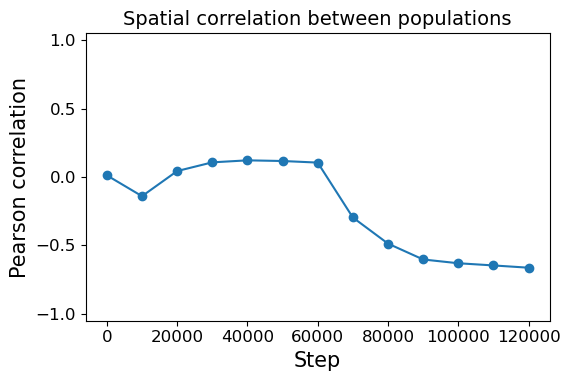

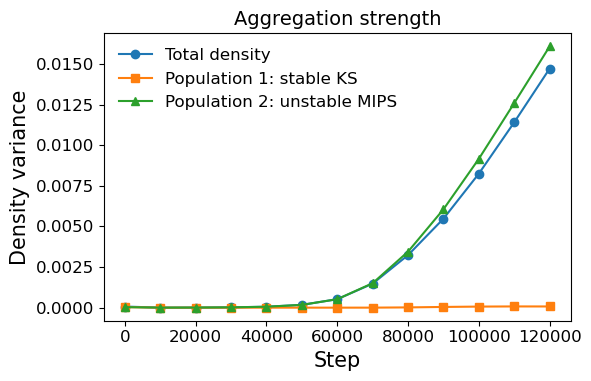

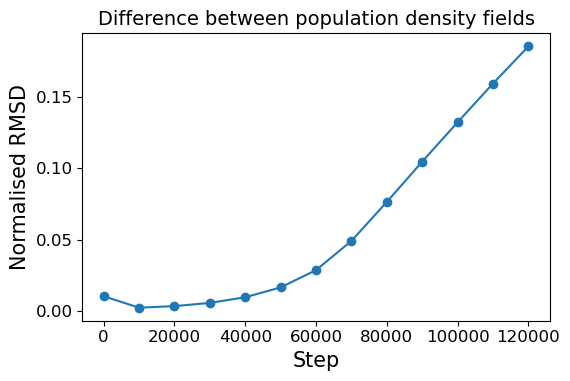

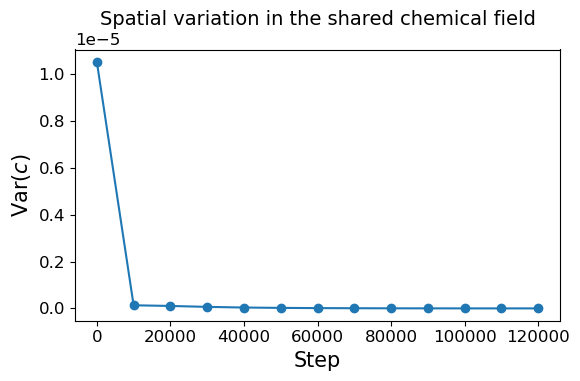

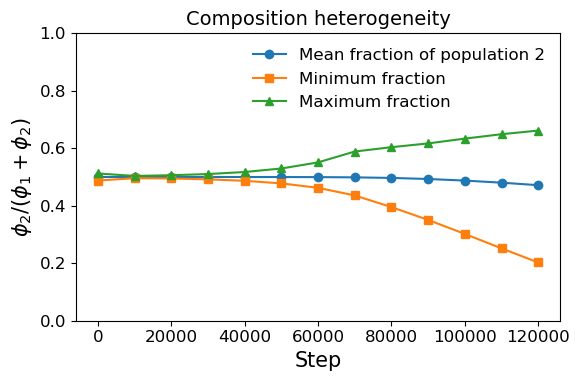

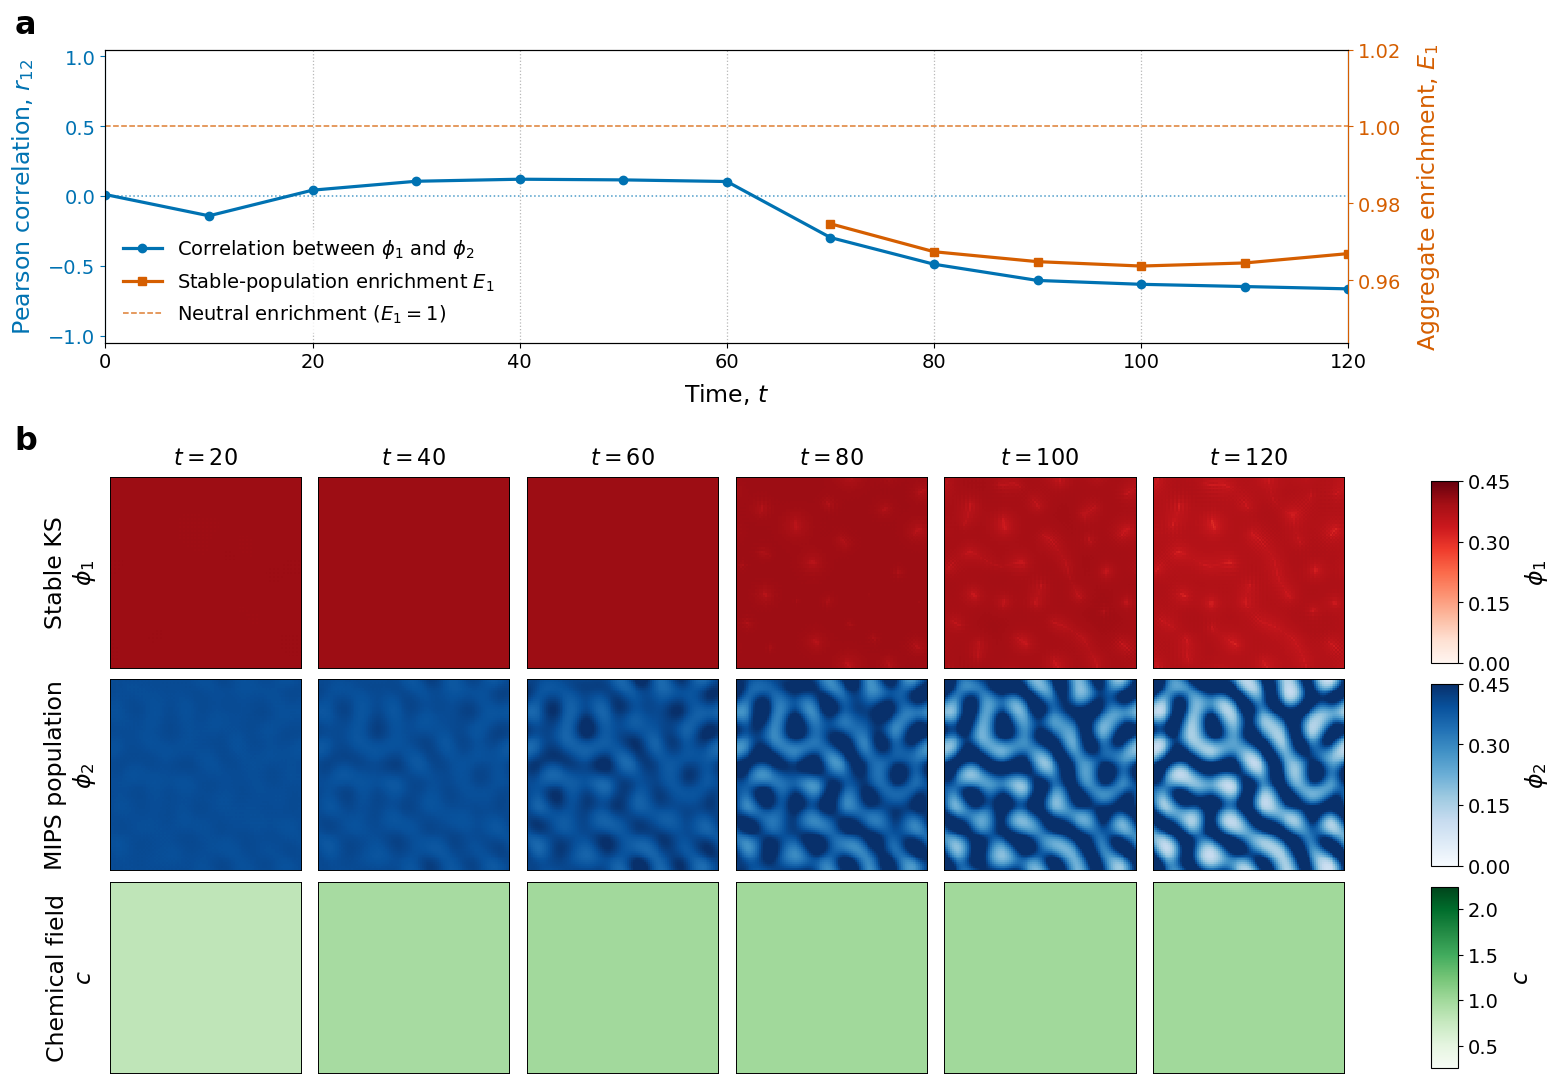

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

# Display settings (simulation parameters and numerical updates unchanged)
SHOW_INTERMEDIATE_PLOTS = False
plt.rcParams.update({
    "font.size": 13, "axes.labelsize": 15, "axes.titlesize": 14,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 12,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})



# Two-population simulation
# Population 1: stable autocrine Keller--Segel population
# Population 2: unstable autocrine CMIPS population
# Both populations produce, remove and respond to one shared chemical field


# 1. Grid and time 
Nx, Ny = 100, 100
dx = 1.0
dt = 0.001
T = 120000
plot_interval = 10000

np.random.seed(1)

# 2. Model parameters 
phi_m = 0.9
phi0_total = 0.8

phi10 = phi0_total / 2
phi20 = phi0_total / 2

D_phi1 = 2.0
M2 = 2.0

Pe_R = 0.001
kappa = 5.0

chi1 = 1.0
chi2 = 1.0

D_c = 1.0

a1 = 0.1
a2 = 0.1

k1 = 0.1
k2 = 0.1

# Fixed threshold used only for the aggregate-enrichment diagnostic
aggregate_threshold = 0.5

alpha1 = D_phi1 / D_c
alpha2 = M2 / D_c

PeC1 = chi1 / D_phi1
PeC2 = chi2 / M2

Da1 = kappa * k1 / D_c
Da2 = kappa * k2 / D_c

print(f"Population 1: stable KS, alpha1 = {alpha1:.3f}, PeC1 = {PeC1:.3f}, Da1 = {Da1:.3f}")
print(f"Population 2: unstable MIPS, alpha2 = {alpha2:.3f}, PeC2 = {PeC2:.3f}, Da2 = {Da2:.3f}")
print(f"a1 = {a1:.3f}, a2 = {a2:.3f}, k1 = {k1:.3f}, k2 = {k2:.3f}")

# 3. Finite-difference operators 
def laplacian(field, spacing):
    return (
        np.roll(field, -1, axis=0) + np.roll(field, 1, axis=0)
        + np.roll(field, -1, axis=1) + np.roll(field, 1, axis=1)
        - 4.0 * field
    ) / spacing**2


def gradient_x(field, spacing):
    return (np.roll(field, -1, axis=0) - np.roll(field, 1, axis=0)) / (2.0 * spacing)


def gradient_y(field, spacing):
    return (np.roll(field, -1, axis=1) - np.roll(field, 1, axis=1)) / (2.0 * spacing)


# 4. MIPS chemical potential 
def compute_mu(phi, phi_m_value, pe_r):
    phi_clipped = np.clip(phi, 1e-6, phi_m_value - 1e-6)
    term1 = np.log(phi_clipped)
    term2 = 1.0 - 2.0 * phi_clipped - 0.3 * phi_clipped**2
    term3 = -(4.0 / np.pi) * pe_r * phi_m_value * (
        np.log(1.0 - phi_clipped / phi_m_value)
        - phi_clipped / phi_m_value
        - phi_clipped
    )
    return term1 + term2 + term3


# 5. Metrics 
def compute_metrics(phi1, phi2):
    phi_total = phi1 + phi2
    x = phi1.flatten()
    y = phi2.flatten()

    if np.std(x) < 1e-12 or np.std(y) < 1e-12:
        pearson = np.nan
    else:
        pearson = np.corrcoef(x, y)[0, 1]

    var_total = np.var(phi_total)
    var_phi1 = np.var(phi1)
    var_phi2 = np.var(phi2)

    rmsd = np.sqrt(np.mean((phi1 - phi2) ** 2))
    rmsd_norm = rmsd / (np.mean(phi_total) + 1e-12)

    frac2 = phi2 / (phi_total + 1e-12)
    mean_frac2 = np.mean(frac2)
    min_frac2 = np.min(frac2)
    max_frac2 = np.max(frac2)

    return pearson, var_total, var_phi1, var_phi2, rmsd_norm, mean_frac2, min_frac2, max_frac2


# 5b. Aggregate enrichment for final figure
def compute_aggregate_enrichment(phi1, phi2, threshold):
    aggregate_mask = phi2 > threshold
    area_fraction = np.mean(aggregate_mask)
    total_phi1_mass = np.sum(phi1)

    if area_fraction < 1e-12 or total_phi1_mass < 1e-12:
        return np.nan, area_fraction

    phi1_mass_inside = np.sum(phi1[aggregate_mask])
    phi1_mass_fraction_inside = phi1_mass_inside / total_phi1_mass
    enrichment1 = phi1_mass_fraction_inside / area_fraction

    return enrichment1, area_fraction


# 6. Plot function 
def plot_snapshot(phi1, phi2, c, step):
    if not SHOW_INTERMEDIATE_PLOTS:
        return
    phi_total = phi1 + phi2
    frac2 = phi2 / (phi_total + 1e-12)

    pearson, var_total, var_phi1, var_phi2, rmsd_norm, mean_frac2, min_frac2, max_frac2 = compute_metrics(phi1, phi2)

    fig, axes = plt.subplots(1, 5, figsize=(21, 4.8))

    im = axes[0].imshow(phi_total, origin="lower", cmap="viridis", vmin=0, vmax=phi_m)
    axes[0].set_title(rf"Total density, step = {step}")
    axes[0].set_xticks([])
    axes[0].set_yticks([])
    cbar = plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
    cbar.set_label(r"$\phi_1+\phi_2$")

    im = axes[1].imshow(phi1, origin="lower", cmap="Reds", vmin=0, vmax=phi_m / 2)
    axes[1].set_title(r"Population 1: stable KS")
    axes[1].set_xticks([])
    axes[1].set_yticks([])
    cbar = plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_label(r"$\phi_1$")

    im = axes[2].imshow(phi2, origin="lower", cmap="Blues", vmin=0, vmax=phi_m / 2)
    axes[2].set_title(r"Population 2: unstable MIPS")
    axes[2].set_xticks([])
    axes[2].set_yticks([])
    cbar = plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    cbar.set_label(r"$\phi_2$")

    im = axes[3].imshow(frac2, origin="lower", cmap="coolwarm", vmin=0, vmax=1)
    axes[3].set_title(r"Fraction of population 2")
    axes[3].set_xticks([])
    axes[3].set_yticks([])
    cbar = plt.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)
    cbar.set_label(r"$\phi_2/(\phi_1+\phi_2)$")

    im = axes[4].imshow(c, origin="lower", cmap="Greens")
    axes[4].set_title(r"Shared chemical field $c$")
    axes[4].set_xticks([])
    axes[4].set_yticks([])
    cbar = plt.colorbar(im, ax=axes[4], fraction=0.046, pad=0.04)
    cbar.set_label(r"$c$")

    plt.suptitle(
        rf"$\alpha_1={alpha1:.2f}$, $\alpha_2={alpha2:.2f}$, "
        rf"$Pe_{{C,1}}={PeC1:.2f}$, $Pe_{{C,2}}={PeC2:.2f}$, "
        rf"$a_1={a1:.2f}$, $a_2={a2:.2f}$, "
        rf"Pearson = {pearson:.2f}, Var(total) = {var_total:.4f}",
        y=1.04
    )

    plt.tight_layout()
    plt.show()


#  7. Initial conditions 
phi1 = phi10 + 0.02 * (np.random.rand(Nx, Ny) - 0.5)
phi2 = phi20 + 0.02 * (np.random.rand(Nx, Ny) - 0.5)

phi1 = np.clip(phi1, 0.0, None)
phi2 = np.clip(phi2, 0.0, None)

# Shared autocrine chemical field:
# dc/dt = D_c lap(c) + a1 phi1 + a2 phi2 - (k1 phi1 + k2 phi2)c
uptake0 = k1 * phi10 + k2 * phi20

if uptake0 <= 0:
    raise ValueError("The homogeneous uptake rate must be positive.")

c0 = (a1 * phi10 + a2 * phi20) / uptake0
c = 0.02 * (np.random.rand(Nx, Ny) - 0.5)
c = np.clip(c, 0.0, None)

print(f"Initial homogeneous chemical steady state c0 = {c0:.4f}")

# 8. Storage 
steps = []

pearson_history = []

var_total_history = []
var_phi1_history = []
var_phi2_history = []

rmsd_history = []

mean_frac2_history = []
min_frac2_history = []
max_frac2_history = []

var_c_history = []

# Additional histories used only for the final composite figure
enrichment1_history = []
aggregate_area_history = []

# Snapshots used only for the final composite figure
snapshot_times = [20, 40, 60, 80, 100, 120]
snapshot_steps = {int(round(time_value / dt)): time_value for time_value in snapshot_times}
phi1_snapshots = {}
phi2_snapshots = {}
c_snapshots = {}


def record_enrichment(phi1, phi2):
    enrichment1, aggregate_area_fraction = compute_aggregate_enrichment(
        phi1, phi2, aggregate_threshold
    )
    enrichment1_history.append(enrichment1)
    aggregate_area_history.append(aggregate_area_fraction)
    return enrichment1, aggregate_area_fraction


def record_metrics(step, phi1, phi2, c):
    pearson, var_total, var_phi1, var_phi2, rmsd_norm, mean_frac2, min_frac2, max_frac2 = compute_metrics(phi1, phi2)

    steps.append(step)
    pearson_history.append(pearson)

    var_total_history.append(var_total)
    var_phi1_history.append(var_phi1)
    var_phi2_history.append(var_phi2)

    rmsd_history.append(rmsd_norm)

    mean_frac2_history.append(mean_frac2)
    min_frac2_history.append(min_frac2)
    max_frac2_history.append(max_frac2)

    var_c_history.append(np.var(c))

    return pearson, var_total, var_phi1, var_phi2, rmsd_norm, mean_frac2, min_frac2, max_frac2


pearson, var_total, var_phi1, var_phi2, rmsd_norm, mean_frac2, min_frac2, max_frac2 = record_metrics(0, phi1, phi2, c)
enrichment1, aggregate_area_fraction = record_enrichment(phi1, phi2)

print(
    f"step = 0, mean total phi = {np.mean(phi1 + phi2):.3f}, "
    f"var total phi = {var_total:.5f}, var phi1 = {var_phi1:.5f}, "
    f"var phi2 = {var_phi2:.5f}, var c = {np.var(c):.6e}, "
    f"Pearson = {pearson:.3f}, RMSD_norm = {rmsd_norm:.3f}, "
    f"mean frac2 = {mean_frac2:.3f}, "
    f"frac2 range = [{min_frac2:.3f}, {max_frac2:.3f}]"
)

plot_snapshot(phi1, phi2, c, step=0)

# 9. Time evolution 
for t in range(1, T + 1):

    phi_total = phi1 + phi2
    phi_total_clipped = np.clip(phi_total, 1e-6, phi_m - 1e-6)

    grad_c_x = gradient_x(c, dx)
    grad_c_y = gradient_y(c, dx)

    # Population 1: stable diffusive KS
    grad_phi1_x = gradient_x(phi1, dx)
    grad_phi1_y = gradient_y(phi1, dx)

    flux1_x = D_phi1 * grad_phi1_x - chi1 * phi1 * grad_c_x
    flux1_y = D_phi1 * grad_phi1_y - chi1 * phi1 * grad_c_y

    # Population 2: MIPS transport based on total density
    mu = compute_mu(phi_total_clipped, phi_m, Pe_R)
    mu_eff = mu - kappa * laplacian(phi_total_clipped, dx)

    grad_mu_x = gradient_x(mu_eff, dx)
    grad_mu_y = gradient_y(mu_eff, dx)

    flux2_x = M2 * phi2 * grad_mu_x - chi2 * phi2 * grad_c_x
    flux2_y = M2 * phi2 * grad_mu_y - chi2 * phi2 * grad_c_y

    div_flux1 = gradient_x(flux1_x, dx) + gradient_y(flux1_y, dx)
    div_flux2 = gradient_x(flux2_x, dx) + gradient_y(flux2_y, dx)

    phi1_new = phi1 + dt * div_flux1
    phi2_new = phi2 + dt * div_flux2

    # One shared autocrine chemical field
    lap_c = laplacian(c, dx)
    production = a1 * phi1 + a2 * phi2
    uptake = (k1 * phi1 + k2 * phi2) * c

    c_new = c + dt * (D_c * lap_c + production - uptake)

    phi1 = np.clip(phi1_new, 0.0, None)
    phi2 = np.clip(phi2_new, 0.0, None)
    c = np.clip(c_new, 0.0, None)

    phi_total = phi1 + phi2
    exceed = phi_total > phi_m

    if np.any(exceed):
        scale = phi_m / (phi_total[exceed] + 1e-12)
        phi1[exceed] *= scale
        phi2[exceed] *= scale

    if t in snapshot_steps:
        snapshot_time = snapshot_steps[t]
        phi1_snapshots[snapshot_time] = phi1.copy()
        phi2_snapshots[snapshot_time] = phi2.copy()
        c_snapshots[snapshot_time] = c.copy()

    if t % plot_interval == 0:

        phi_total = phi1 + phi2

        pearson, var_total, var_phi1, var_phi2, rmsd_norm, mean_frac2, min_frac2, max_frac2 = record_metrics(t, phi1, phi2, c)
        enrichment1, aggregate_area_fraction = record_enrichment(phi1, phi2)

        print(
            f"step = {t}, mean total phi = {np.mean(phi_total):.3f}, "
            f"var total phi = {var_total:.5f}, var phi1 = {var_phi1:.5f}, "
            f"var phi2 = {var_phi2:.5f}, var c = {np.var(c):.6e}, "
            f"Pearson = {pearson:.3f}, RMSD_norm = {rmsd_norm:.3f}, "
            f"mean frac2 = {mean_frac2:.3f}, "
            f"frac2 range = [{min_frac2:.3f}, {max_frac2:.3f}]"
        )

        plot_snapshot(phi1, phi2, c, step=t)

# 10. Convert histories to arrays
steps = np.array(steps)

pearson_history = np.array(pearson_history)

var_total_history = np.array(var_total_history)
var_phi1_history = np.array(var_phi1_history)
var_phi2_history = np.array(var_phi2_history)

rmsd_history = np.array(rmsd_history)

mean_frac2_history = np.array(mean_frac2_history)
min_frac2_history = np.array(min_frac2_history)
max_frac2_history = np.array(max_frac2_history)

var_c_history = np.array(var_c_history)
enrichment1_history = np.array(enrichment1_history)
aggregate_area_history = np.array(aggregate_area_history)
times = steps * dt

# 11. Diagnostic plots

plt.figure(figsize=(6, 4))
plt.plot(steps, pearson_history, marker="o")
plt.xlabel("Step")
plt.ylabel("Pearson correlation")
plt.ylim(-1.05, 1.05)
plt.title("Spatial correlation between populations")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(steps, var_total_history, marker="o", label="Total density")
plt.plot(steps, var_phi1_history, marker="s", label="Population 1: stable KS")
plt.plot(steps, var_phi2_history, marker="^", label="Population 2: unstable MIPS")
plt.xlabel("Step")
plt.ylabel("Density variance")
plt.title("Aggregation strength")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(steps, rmsd_history, marker="o")
plt.xlabel("Step")
plt.ylabel("Normalised RMSD")
plt.title("Difference between population density fields")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(steps, var_c_history, marker="o")
plt.xlabel("Step")
plt.ylabel(r"$\mathrm{Var}(c)$")
plt.title("Spatial variation in the shared chemical field")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(steps, mean_frac2_history, marker="o", label="Mean fraction of population 2")
plt.plot(steps, min_frac2_history, marker="s", label="Minimum fraction")
plt.plot(steps, max_frac2_history, marker="^", label="Maximum fraction")
plt.xlabel("Step")
plt.ylabel(r"$\phi_2/(\phi_1+\phi_2)$")
plt.ylim(0, 1)
plt.title("Composition heterogeneity")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


# 12. Final composite figure (plotting only)
# This section can also be rerun on its own after the original
# simulation has populated the history arrays and snapshot dictionaries.
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.ticker import MaxNLocator

LABEL_SIZE = 17
TICK_SIZE = 14
LEGEND_SIZE = 14
PANEL_SIZE = 23
TIME_SIZE = 16
CORR_COLOR = "#0072B2"
ENRICH_COLOR = "#D55E00"

for snapshot_time in snapshot_times:
    for name, snapshots in [
        ("phi1", phi1_snapshots),
        ("phi2", phi2_snapshots),
        ("c", c_snapshots),
    ]:
        if snapshot_time not in snapshots:
            raise RuntimeError(f"Missing {name} snapshot at t={snapshot_time}")

plot_times = np.asarray(times, dtype=float)
plot_pearson = np.asarray(pearson_history, dtype=float)
plot_enrichment = np.asarray(enrichment1_history, dtype=float)
time_edges = np.r_[0.0, np.asarray(snapshot_times, dtype=float)]
column_widths = np.diff(time_edges)
if np.any(column_widths <= 0):
    raise ValueError("snapshot_times must be positive and strictly increasing")
n_snapshots = len(snapshot_times)

# Retain the original density color limits to preserve comparability.
# Values above phi_m/2 will retain the original saturated display.
phi1_vmin, phi1_vmax = 0.0, phi_m / 2
phi2_vmin, phi2_vmax = 0.0, phi_m / 2
# Preserve the fixed chemical scale from the supplied autocrine code.
# Use identical limits in the minimal-signaling figure if comparing colors.
chemical_vmin = 0.25
chemical_vmax = 2.25
c_vmin, c_vmax = chemical_vmin, chemical_vmax

fig = plt.figure(figsize=(16.5, 11.5))
outer_gs = GridSpec(
    2, 2, figure=fig,
    height_ratios=[1.55, 3.15],
    width_ratios=[1.0, 0.022],
    left=0.10, right=0.92, bottom=0.06, top=0.95,
    hspace=0.30, wspace=0.13,
)
snapshot_gs = GridSpecFromSubplotSpec(
    3, n_snapshots, subplot_spec=outer_gs[1, 0],
    width_ratios=column_widths, hspace=0.06, wspace=0.045,
)
cbar_gs = GridSpecFromSubplotSpec(
    3, 1, subplot_spec=outer_gs[1, 1], hspace=0.06,
)

# (a) Correlation and enrichment, with distinct colors and axes.
ax_top = fig.add_subplot(outer_gs[0, 0])
ax_top_right = ax_top.twinx()
pearson_line, = ax_top.plot(
    plot_times, plot_pearson,
    color=CORR_COLOR, marker="o", markersize=6, linewidth=2.3,
    label=r"Correlation between $\phi_1$ and $\phi_2$",
)
enrichment_line, = ax_top_right.plot(
    plot_times, plot_enrichment,
    color=ENRICH_COLOR, marker="s", markersize=6, linewidth=2.3,
    label=r"Stable-population enrichment $E_1$",
)
ax_top.axhline(0, color=CORR_COLOR, linestyle=":", linewidth=1.1, alpha=0.7)
neutral_line = ax_top_right.axhline(
    1, color=ENRICH_COLOR, linestyle="--", linewidth=1.1,
    alpha=0.8, label=r"Neutral enrichment ($E_1=1$)",
)
for boundary in snapshot_times[:-1]:
    ax_top.axvline(boundary, color="0.72", linestyle=":", linewidth=0.9, zorder=0)

ax_top.set_xlim(0, snapshot_times[-1])
ax_top.set_xticks(time_edges)
ax_top.set_ylim(-1.05, 1.05)
ax_top.set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0])
ax_top.set_xlabel(r"Time, $t$", fontsize=LABEL_SIZE, labelpad=7)
ax_top.set_ylabel(r"Pearson correlation, $r_{12}$", fontsize=LABEL_SIZE,
                  color=CORR_COLOR, labelpad=9)
ax_top_right.set_ylabel(r"Aggregate enrichment, $E_1$", fontsize=LABEL_SIZE,
                        color=ENRICH_COLOR, labelpad=10)
ax_top.tick_params(axis="x", labelsize=TICK_SIZE)
ax_top.tick_params(axis="y", labelsize=TICK_SIZE, colors=CORR_COLOR)
ax_top_right.tick_params(axis="y", labelsize=TICK_SIZE, colors=ENRICH_COLOR)
ax_top.spines["left"].set_color(CORR_COLOR)
ax_top_right.spines["right"].set_color(ENRICH_COLOR)
ax_top_right.yaxis.set_major_locator(MaxNLocator(nbins=5))

finite_enrichment = plot_enrichment[np.isfinite(plot_enrichment)]
if finite_enrichment.size:
    lo = min(1.0, float(finite_enrichment.min()))
    hi = max(1.0, float(finite_enrichment.max()))
    padding = max(0.02, 0.12 * (hi - lo))
    ax_top_right.set_ylim(lo - padding, hi + padding)
else:
    ax_top_right.set_ylim(0.95, 1.05)

ax_top.legend(
    handles=[pearson_line, enrichment_line, neutral_line],
    loc="lower left", fontsize=LEGEND_SIZE,
    frameon=True, facecolor="white", edgecolor="none", framealpha=0.85,
)

# (b) Spatial maps: all three row labels are vertical.
row_specs = [
    (phi1_snapshots, "Reds", phi1_vmin, phi1_vmax,
     "Stable KS" + "\n" + r"$\phi_1$", r"$\phi_1$"),
    (phi2_snapshots, "Blues", phi2_vmin, phi2_vmax,
     "MIPS population" + "\n" + r"$\phi_2$", r"$\phi_2$"),
    (c_snapshots, "Greens", c_vmin, c_vmax,
     "Chemical field" + "\n" + r"$c$", r"$c$"),
]
row_axes = []
cbar_axes = []
for row_index, (snapshots, cmap, vmin, vmax, row_label, cbar_label) in enumerate(row_specs):
    current_axes = []
    for column_index, snapshot_time in enumerate(snapshot_times):
        ax = fig.add_subplot(snapshot_gs[row_index, column_index])
        im = ax.imshow(
            snapshots[snapshot_time], origin="lower", cmap=cmap,
            vmin=vmin, vmax=vmax, interpolation="nearest", aspect="equal",
        )
        ax.set_xticks([])
        ax.set_yticks([])
        if row_index == 0:
            ax.set_title(rf"$t={snapshot_time:g}$", fontsize=TIME_SIZE, pad=9)
        if column_index == 0:
            ax.set_ylabel(row_label, rotation=90, fontsize=LABEL_SIZE,
                          labelpad=28, va="center", ha="center")
        for spine in ax.spines.values():
            spine.set_linewidth(0.7)
        current_axes.append(ax)
    row_axes.append(current_axes)
    cax = fig.add_subplot(cbar_gs[row_index, 0])
    cb = fig.colorbar(im, cax=cax)
    cb.set_label(cbar_label, fontsize=LABEL_SIZE, labelpad=8)
    cb.ax.tick_params(labelsize=TICK_SIZE)
    cb.locator = MaxNLocator(nbins=4)
    cb.update_ticks()
    cb.ax.yaxis.get_offset_text().set_fontsize(TICK_SIZE - 1)
    cbar_axes.append(cax)

# Center each colorbar on its row; slight shortening separates adjacent tick labels.
fig.canvas.draw()
for current_axes, cax in zip(row_axes, cbar_axes):
    image_pos = current_axes[-1].get_position()
    cbar_pos = cax.get_position()
    cax.set_position([cbar_pos.x0, image_pos.y0 + 0.025 * image_pos.height,
                      cbar_pos.width, 0.95 * image_pos.height])

# Use one shared horizontal position for both panel letters.
panel_x = outer_gs.left - 0.055
fig.text(panel_x, ax_top.get_position().y1 + 0.008, "a",
         fontsize=PANEL_SIZE, fontweight="bold", va="bottom")
fig.text(panel_x, row_axes[0][0].get_position().y1 + 0.018, "b",
         fontsize=PANEL_SIZE, fontweight="bold", va="bottom")

plt.show()